In [29]:
# 讀取資料
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 設定路徑 (注意：在 ipynb 中 __file__ 可能失效，若報錯請直接寫檔名)
# 如果檔案就在同個資料夾，可以直接用 pd.read_csv('train.csv')
train_path = '../train.csv'
test_path = '../test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 建立 X 與 y
X_train = df_train.drop(['quality', 'Id'], axis=1)
y_train = df_train['quality']
X_test = df_test.drop(['quality', 'Id'], axis=1)
y_test = df_test['quality']

print("資料讀取完畢！")

資料讀取完畢！


In [ ]:
# ==搜尋最佳參數組合== 
# n_estimators : 最大子樹數量
# max_depth : 每棵樹的最大深度
# max_features : 每次分裂時，抽取隨機的特徵數 
# min_samples_leaf : 葉子節點所需的最小樣本數   
param_grid = {
    'n_estimators': [50, 100, 200, 300],    
    'max_depth': [3, 5, 7, 10, None],       
    'max_features': [2, 3, 4, 6, None],     
    'min_samples_leaf': [5, 10, 20]        
}


# 執行搜尋 : cv 分為五組，每次選一組出來當驗證集，其他四組當作訓練集，最後分數取平均
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=1, return_train_score=True)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
最佳參數組合： {'max_depth': None, 'max_features': 3, 'min_samples_leaf': 5, 'n_estimators': 200}


In [76]:
# 1. 取得 GridSearchCV 的所有結果並轉成 DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. 依照排名排序，取前 10 名
top_10_results = results_df.sort_values(by='rank_test_score').head(10)

# 3. 準備一個清單來存儲結果
comparison_list = []

print("正在評估前 10 名模型...\n")

# 4. 遍歷前 10 名的參數索引
for index in top_10_results.index:
    # 取得該排名的參數
    params = results_df.loc[index, 'params']
    
    # 用這組參數重新建立一個模型（或是從 cv_results 直接取值，但重新 score 最保險）
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    
    # 計算分數
    train_acc = model.score(X_train, y_train) * 100
    test_acc = model.score(X_test, y_test) * 100
    gap = train_acc - test_acc
    
    # 存入清單
    comparison_list.append({
        'Rank': results_df.loc[index, 'rank_test_score'],
        'Train Acc': f"{train_acc:.2f}%",
        'Test Acc': f"{test_acc:.2f}%",
        'Gap': f"{gap:.2f}%",
        'Params': params
    })

# 5. 轉換成 DataFrame 顯示
final_comparison = pd.DataFrame(comparison_list)
print(final_comparison.to_string(index=False))

正在評估前 10 名模型...

 Rank Train Acc Test Acc    Gap                                                                             Params
    1    84.90%   64.19% 20.71% {'max_depth': None, 'max_features': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
    2    82.71%   65.07% 17.65%   {'max_depth': 10, 'max_features': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
    3    84.35%   64.19% 20.16% {'max_depth': None, 'max_features': 4, 'min_samples_leaf': 5, 'n_estimators': 300}
    4    84.25%   64.19% 20.05% {'max_depth': None, 'max_features': 4, 'min_samples_leaf': 5, 'n_estimators': 200}
    5    85.78%   62.88% 22.89% {'max_depth': None, 'max_features': 6, 'min_samples_leaf': 5, 'n_estimators': 200}
    6    84.79%   64.19% 20.60% {'max_depth': None, 'max_features': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
    7    83.37%   62.45% 20.92%   {'max_depth': 10, 'max_features': 2, 'min_samples_leaf': 5, 'n_estimators': 200}
    8    83.92%   62.01% 21.91% {'max_depth': None, 'max_featur

訓練集準確率: 82.71%
測試集準確率: 65.07%


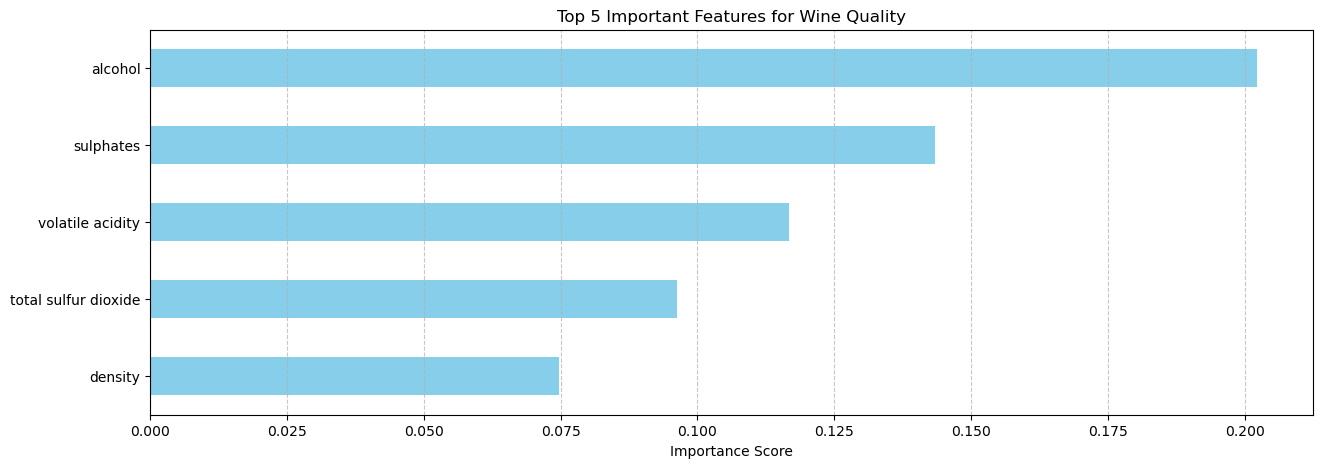

In [83]:
clf = RandomForestClassifier(max_depth=10, max_features=3, min_samples_leaf=5,n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
# 印出準確率

print(f"訓練集準確率: {clf.score(X_train, y_train)*100:.2f}%")
print(f"測試集準確率: {clf.score(X_test, y_test)*100:.2f}%")

# 畫圖：前五名重要特徵
importances = clf.feature_importances_ 
feat_importances = pd.Series(importances, index=X_train.columns).nlargest(5)

plt.figure(figsize=(15, 5))                              # 設定畫布大小
feat_importances.plot(kind='barh', color='skyblue')      # barh : 水平長條圖
plt.title('Top 5 Important Features for Wine Quality')   # 標題
plt.xlabel('Importance Score')                           # x 軸標籤
plt.gca().invert_yaxis()                                 # 反轉 y 軸
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()